In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("/content/superstore_final_dataset (1).csv", encoding='latin1')
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [6]:
df.isnull().sum()

,0
Row_ID,0
Order_ID,0
Order_Date,0
Ship_Date,0
Ship_Mode,0
Customer_ID,0
Customer_Name,0
Segment,0
Country,0
City,0


In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.fillna(0, inplace=True)

In [9]:
df.shape

(9800, 18)

In [11]:
df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category',
       'Product_Name', 'Sales'],
      dtype='object')

In [15]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d/%m/%Y')

In [16]:
df['Order_Date'].dtype

dtype('<M8[ns]')

In [17]:
df['Order_Month'] = df['Order_Date'].dt.month

In [18]:
df['Order_Month'] = df['Order_Date'].dt.month

In [19]:
df[['Order_Date', 'Order_Month']].head()

,Order_Date,Order_Month
0,2017-11-08,11
1,2017-11-08,11
2,2017-06-12,6
3,2016-10-11,10
4,2016-10-11,10


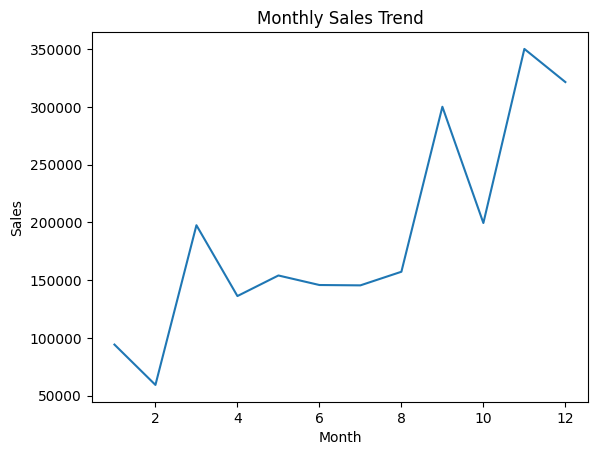

In [20]:
monthly_sales = df.groupby('Order_Month')['Sales'].sum()

monthly_sales.plot(kind='line')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.show()

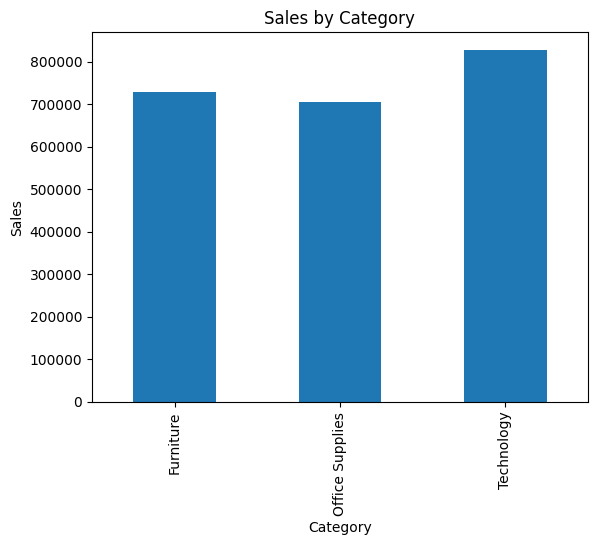

In [21]:
df.groupby('Category')['Sales'].sum().plot(kind='bar')

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')

plt.show()

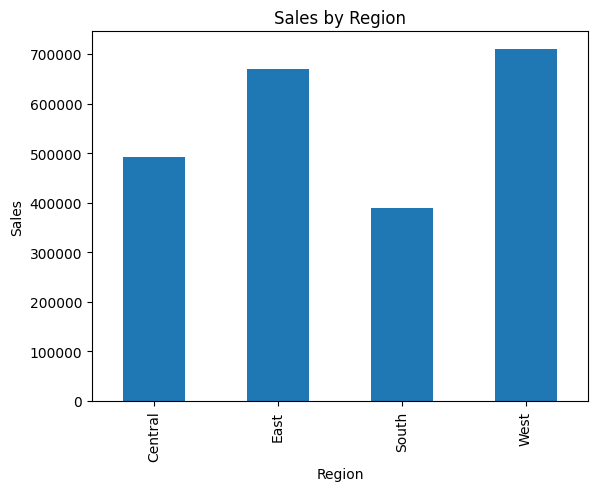

In [22]:
df.groupby('Region')['Sales'].sum().plot(kind='bar')

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')

plt.show()

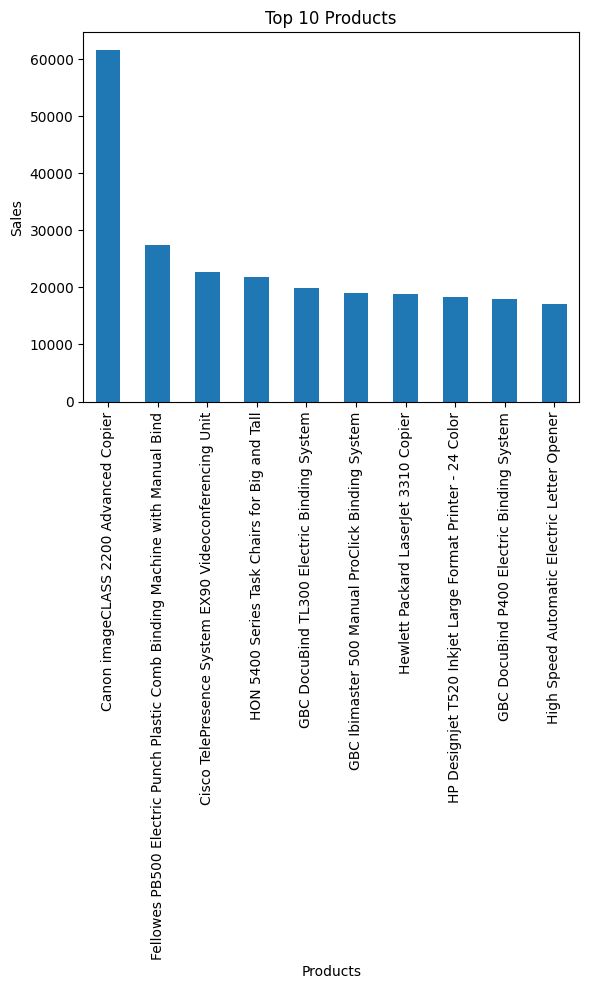

In [23]:
top_products = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')

plt.title('Top 10 Products')
plt.xlabel('Products')
plt.ylabel('Sales')

plt.show()

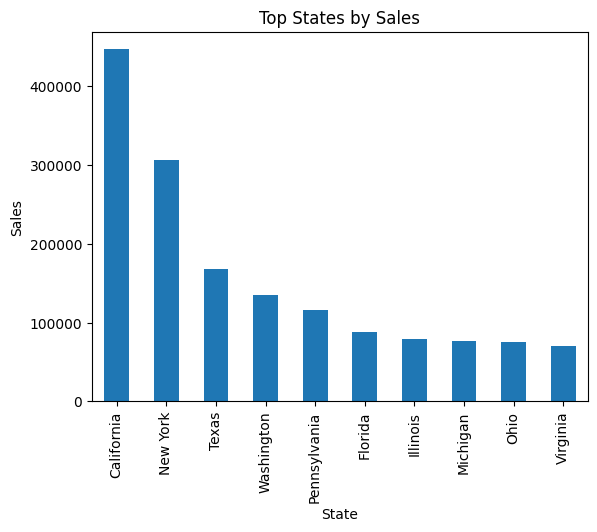

In [24]:
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

top_states.plot(kind='bar')

plt.title('Top States by Sales')
plt.xlabel('State')
plt.ylabel('Sales')

plt.show()

In [25]:
total_sales = df['Sales'].sum()

print("Total Sales:", total_sales)

Total Sales: 2261536.7827000003


In [26]:
average_sales = df['Sales'].mean()

print("Average Sales:", average_sales)

Average Sales: 230.7690594591837


In [27]:
highest_product = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(1)

print(highest_product)

Product_Name
Canon imageCLASS 2200 Advanced Copier    61599.824
Name: Sales, dtype: float64


In [28]:
highest_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False).head(1)

print(highest_region)

Region
West    710219.6845
Name: Sales, dtype: float64


In [29]:
highest_state = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(1)

print(highest_state)

State
California    446306.4635
Name: Sales, dtype: float64
